## Comparing our results

In [1]:
# Imports
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

from block_encoding import generate_laplacian_block_encoding
from shift_operators import ShiftDown, ShiftUp
from utils import get_circuit_unitary, plot_heatmap

### Other block-encodings

In [2]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import RYGate

def camps_banded_circulant_mat(nq, alpha, beta, gamma, tridiag=False, save_unitary=True):
    """https://arxiv.org/pdf/2203.10236"""
    
    assert 0 <= alpha
    assert alpha <= 2
    assert abs(beta) <= 1
    assert abs(gamma) <= 1

    j_reg = QuantumRegister(nq, "j")
    data_reg = QuantumRegister(1, "data")
    l_reg = QuantumRegister(2, "l")
    

    qc = QuantumCircuit(j_reg, l_reg, data_reg)

    # Diffusion
    qc.h(l_reg)

    # OA
    theta0 = 2 * np.arccos(alpha - 1)
    theta1 = 2 * np.arccos(beta)
    theta2 = 2 * np.arccos(gamma)

    qc.append(RYGate(theta0).control(2, ctrl_state="00"), l_reg[:] + data_reg[:])
    qc.append(RYGate(theta1).control(2, ctrl_state="01"), l_reg[:] + data_reg[:])
    qc.append(RYGate(theta2).control(2, ctrl_state="10"), l_reg[:] + data_reg[:])

    if tridiag:
        qc.append(RYGate(np.pi - theta1).control(nq + 2, ctrl_state="1" * nq + "01"), l_reg[:] + j_reg[:] + data_reg[:])
        qc.append(RYGate(np.pi - theta2).control(nq + 2, ctrl_state="0" * nq + "10"), l_reg[:] + j_reg[:] + data_reg[:])

    # OC
    qc.append(ShiftUp(nq).control(1), [l_reg[0]] + j_reg[:])
    qc.append(ShiftDown(nq).control(1), [l_reg[1]] + j_reg[:])

    # Diffusion
    qc.h(l_reg)

    if save_unitary:
        qc.save_unitary()

    return qc

In [3]:
import math
from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.circuit.library import *
from qiskit.quantum_info import Operator


def unique_val_lap(laplacian, Nx):
    """Extract unique diagonal values from a 2D Laplacian matrix."""
    unique_values = [
        laplacian.diagonal(0)[0],  # Main diagonal (A0)
        laplacian.diagonal(1)[0],  # Next lower diagonal (A1)
        laplacian.diagonal(Nx)[0], # Final diagonal (A2)
    ]
    return unique_values

def make_incrementer(n: int):
    circ = QuantumCircuit(n, name=f"INC{n}")
    for i in range(n-1, 0, -1): 
        circ.mcx(list(range(i)), i)
    circ.x(0)
    return circ.to_gate()

def make_decrementer(n: int):
    inc = make_incrementer(n)
    dec = inc.inverse()
    dec.name = f"DEC{n}"
    return dec

def prep_lap(reg: QuantumRegister, vec: list[float]):
    qc = QuantumCircuit(reg)
    prep = StatePreparation(vec)  
    qc.append(prep, reg)  
    return qc

def unprep_lap(reg: QuantumRegister, vec: list[float]):
    prep_qc = prep_lap(reg, vec)
    unitary = Operator(prep_qc).data
    inv_unitary = np.conj(unitary.T) 
    qc = QuantumCircuit(reg)
    prep_inv_gate = UnitaryGate(inv_unitary) 
    qc.append(prep_inv_gate, reg) 
    return qc

def oracle_org(qc, dl_reg, j_reg, s_reg, j1, j2, jx, jy): 
    oracle_100 = XGate().control(3, ctrl_state='001') 
    qc.append(oracle_100, [s_reg[0], s_reg[1], s_reg[2], dl_reg[0]])
    oracle_01_jy = XGate().control(j1+1, ctrl_state=('1'+'0'*j1)) 
    qc.append(oracle_01_jy, jx + [s_reg[1], dl_reg[0]])
    oracle_01_jx = XGate().control(j2+1, ctrl_state=('1'+'0'*j2))   
    qc.append(oracle_01_jx, jy + [s_reg[2], dl_reg[0]])

def oracle_d(qc: QuantumCircuit,
             TM: list[float],
             data_regs: list,
             s_reg: list):
    """
    Apply a multi‐controlled RX on each data qubit in data_regs,
    with angles 2*arccos(TM[i]) controlled on the bitstring i of s_reg[1:].
    
    Args:
        qc        : your QuantumCircuit
        TM        : list of length 2**n_controls of amplitudes
        data_regs : list of target qubits (e.g. [data_reg[0]])
        s_reg     : full s register (we’ll use s_reg[1:] as controls)
    """ 
    controls  = [s_reg[1], s_reg[2]] 
    n_ctrl = len(controls)
    
    if len(TM) != 2**n_ctrl:
        raise ValueError(f"TM must have length 2**{n_ctrl} (got {len(TM)})")
    
    for i, amp in enumerate(TM):
        angle      = 2*np.arccos(amp)
        ctrl_state = format(i, '02b')         
        gate = RXGate(angle).control(2, ctrl_state=ctrl_state) 
        qc.append(gate, controls + [data_regs[0]])
    
    return qc


def sunderhauff_block_encoding(
    Nx, Ny, scaled_laplacian, v_normed=None, save_unitary=True
):

    unique_values_laplacian = unique_val_lap(scaled_laplacian, Nx)
    unique_values_laplacian.append(0)

    data_reg = QuantumRegister(1, "data")
    dlt_reg = QuantumRegister(1, "dlt")
    s_reg = QuantumRegister(3, "s")  # Corresponds to s0, s1, s2
    j1, j2 = int(math.log2(Nx)), int(math.log2(Ny))
    j_reg = QuantumRegister(j1 + j2, "j")
    jx, jy = j_reg[:j1], j_reg[j1:]
    qc = QuantumCircuit(j_reg, s_reg, dlt_reg, data_reg)

    if v_normed is not None:
        qc.append(StatePreparation(v_normed), j_reg)

    vec = [
        np.sqrt(1 / 5),
        0,
        np.sqrt(1 / 5),
        np.sqrt(1 / 5),
        np.sqrt(1 / 5),
        np.sqrt(1 / 5),
        0,
        0,
    ]

    prep = prep_lap(s_reg, vec)
    qc.append(prep, s_reg)

    add_1_to_jy = make_incrementer(j2).control(2, ctrl_state="10")
    add_1_to_j = make_incrementer(int(j1 + j2)).control(2, ctrl_state="10")
    qc.append(add_1_to_jy, [s_reg[0], s_reg[2]] + jy)  # [::-1]
    qc.append(add_1_to_j, [s_reg[0], s_reg[1]] + list(j_reg))  # [::-1]

    oracle_org(qc, dlt_reg, j_reg, s_reg, j1, j2, jx, jy)
    qc.z(data_reg[0])
    oracle_d(qc, unique_values_laplacian, data_reg, s_reg)
    qc.cx(s_reg[1], s_reg[0])
    qc.cx(s_reg[2], s_reg[0])

    sub_1_to_jx = make_decrementer(int(j1 + j2)).control(2, ctrl_state="10")
    qc.append(sub_1_to_jx, [s_reg[0], s_reg[1]] + list(j_reg))
    sub_1_to_j = make_decrementer(j2).control(2, ctrl_state="10")
    qc.append(sub_1_to_j, [s_reg[0], s_reg[2]] + jy)

    prep_dagger = unprep_lap(s_reg, vec)
    qc.append(prep_dagger, s_reg)

    if save_unitary:
        qc.save_unitary()

    return qc
 

In [4]:
# Manually computed Laplacian matrices
def lap1d_fd(n, h=1.0, bc="dirichlet"):
    """
    Build 1D second-order finite-difference  (standard 3-point centered (central) finite-difference discretization for the second derivative) 
    Laplacian for `n` grid points with spacing `h` and boundary condition `bc`.

    Parameters
    ----------
    n : int
        Number of grid points (nodes) along the 1D domain (>=1).
    h : float
        Grid spacing.
    bc : {'dirichlet','neumann','periodic'}
        Boundary condition type:
          - 'dirichlet' : u=0 at boundaries (standard tridiagonal).
          - 'neumann'   : zero-flux (one-sided treatment at endpoints).
          - 'periodic'  : wrap-around neighbors (circulant/tridiagonal with corners).

    Returns
    -------
    A : scipy.sparse.csr_matrix, shape (n,n)
        Sparse 1D Laplacian matrix (second derivative approximation) scaled by 1/h^2.
    """
    if n < 1:
        raise ValueError("n must be >= 1")

    main = -2.0 / (h * h)
    off = 1.0 / (h * h)

    # tridiagonal base (LIL for easy element assignment)
    A = sp.diags(
        [off * np.ones(n - 1), main * np.ones(n), off * np.ones(n - 1)],
        offsets=[-1, 0, 1],
        shape=(n, n),
        format="lil",
    )

    if bc == "periodic":
        # wrap-around entries
        if n >= 2:
            A[0, n - 1] = off
            A[n - 1, 0] = off
        else:
            # n == 1: Laplacian on single periodic point is zero
            A[0, 0] = 0.0

    elif bc == "neumann":
        if n == 1:
            A[0, 0] = 0.0
        else:
            # Neumann BC 
            A[0, 0] = -1.0 / (h * h)
            A[0, 1] =  1.0 / (h * h)

            A[n - 1, n - 2] =  1.0 / (h * h)
            A[n - 1, n - 1] = -1.0 / (h * h)

    else:
        # Dirichlet: standard tridiagonal (rows kept as is).
        pass

    return A.tocsr()


def generate_laplacian(shape, deltas=None, bcs=None, analytic_normalize=False):
    """
    Build separable FD Laplacian and optionally apply analytic normalization ().

    Parameters
    ----------
    shape : tuple of ints
        Number of grid points per axis (Nx, Ny, ...).
    deltas : tuple of floats or None
        Grid spacings per axis (hx, hy, ...). If None, uses 1.0 for each axis.
    bcs : str or tuple-of-str or None
        Boundary conditions per axis. If None, uses 'dirichlet' on all axes.
    analytic_normalize : bool
        If True, scale the assembled Laplacian by lambda_max = 4 * sum_i (1/h_i^2). 
        Returns (A_scaled, lambda_max). If False, returns A only. (We use the same analytical scaling factor as in the Sturm et al. 2025 paper.)

    Returns
    -------
    A or A_scaled
    """

    shape = tuple(shape)
    D = len(shape)
    if deltas is None:
        deltas = tuple([1.0] * D)
    else:
        deltas = tuple(deltas)

    if bcs is None:
        bcs = tuple(["dirichlet"] * D)
    elif isinstance(bcs, str):
        bcs = tuple([bcs] * D)
    else:
        bcs = tuple(bcs)

    # Build 1D operators
    ops_1d = [lap1d_fd(n, h, bc) for (n, h, bc) in zip(shape, deltas, bcs)]

    # Build Kronecker-sum: sum_k (I ⊗ ... ⊗ K_k ⊗ ... ⊗ I) # just like in the third reference paper (Sturm et al. 2015)
    total = None
    for axis, K in enumerate(ops_1d):
        # left identity: product of identity matrices for axes > axis
        kron_left = sp.eye(1, format="csr")
        for j in range(D - 1, axis, -1):
            kron_left = sp.kron(sp.eye(shape[j], format="csr"), kron_left, format="csr")

        # right identity: product for axes < axis
        kron_right = sp.eye(1, format="csr")
        for j in range(0, axis):
            kron_right = sp.kron(kron_right, sp.eye(shape[j], format="csr"), format="csr")

        term = sp.kron(kron_left, sp.kron(K, kron_right, format="csr"), format="csr")
        total = term if total is None else (total + term)

    A = total.tocsr()

    if analytic_normalize:  # again the same scaling factor as in the Sturm et al. 2025 paper
        # analytic lambda_max = 4 * sum_i (1 / h_i^2)
        lambda_max = 4.0 * sum((1.0 / (h * h)) for h in deltas)
        if lambda_max <= 0:
            raise ValueError("Computed lambda_max <= 0; check grid spacings.")
        A_scaled = A / lambda_max
        return A_scaled.tocsr()
    else:
        return A


## Benchmarking
Metrics used: circuit depth, 2-qubit gate count, and total number of gates

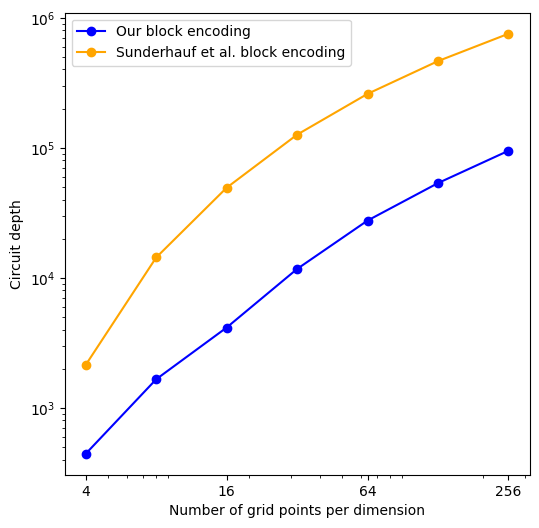

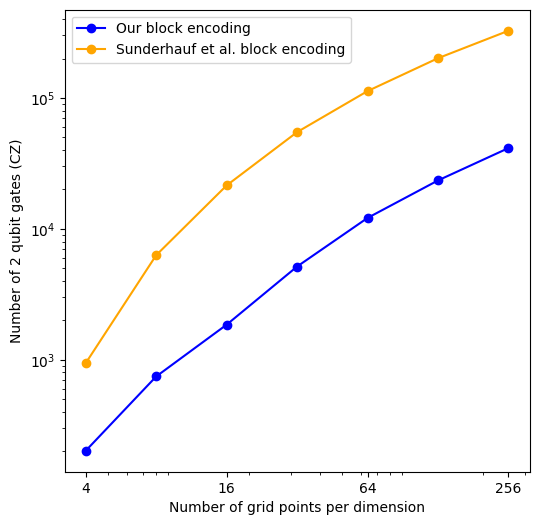

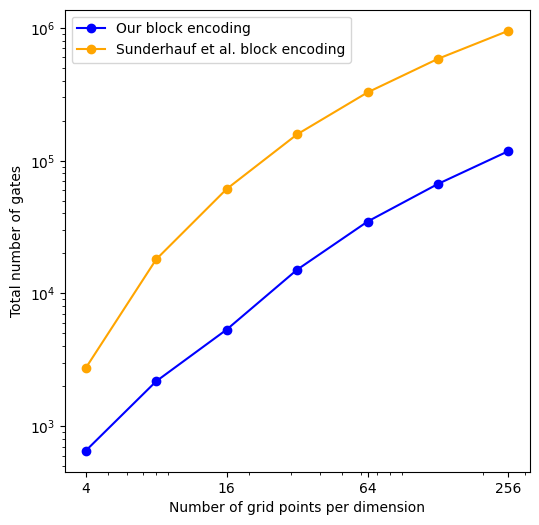

In [5]:
# 2D Dirichlet Laplacian gate count
basis_gates = ["cz", "id", "rx", "rz", "rzz", "sx", "x"]  # Heron QPU basis gates

nq = list(range(2, 9))
npoints = 2 ** np.array(nq)

our_be_2qg = []
sunderhauf_be_2qg = []

our_be_total_gates = []
sunderhauf_be_total_gates = []

our_be_depth = []
sunderhauf_be_depth = []


for nq1 in nq:
    # Correct Laplacian matrix
    lap = generate_laplacian((2**nq1, 2**nq1), analytic_normalize=True)

    # Our block encoding
    qc = generate_laplacian_block_encoding([nq1, nq1], save_unitary=False)
    transpiled = transpile(qc, basis_gates=basis_gates)

    counts = transpiled.count_ops()
    twoq_count = counts["cz"] + counts["rzz"]

    our_be_depth.append(transpiled.depth())
    our_be_2qg.append(twoq_count)
    our_be_total_gates.append(sum(counts.values()))

    # Sunderhauff et al. block encoding
    qc = sunderhauff_block_encoding(2**nq1, 2**nq1, lap, save_unitary=False)
    transpiled = transpile(qc, basis_gates=basis_gates)

    counts = transpiled.count_ops()
    twoq_count = counts["cz"] + counts["rzz"]

    sunderhauf_be_depth.append(transpiled.depth())
    sunderhauf_be_2qg.append(twoq_count)
    sunderhauf_be_total_gates.append(sum(counts.values()))


plt.figure(figsize=(6, 6))
plt.plot(npoints, our_be_depth, "o-", color="blue", label="Our block encoding")
plt.plot(
    npoints,
    sunderhauf_be_depth,
    "o-",
    color="orange",
    label="Sunderhauf et al. block encoding",
)
plt.xscale("log")
plt.xlabel("Number of grid points per dimension")
plt.yscale("log")
plt.ylabel("Circuit depth")
plt.xticks(npoints[::2], labels=npoints[::2])
plt.legend()
plt.show()


plt.figure(figsize=(6, 6))
plt.plot(npoints, our_be_2qg, "o-", color="blue", label="Our block encoding")
plt.plot(
    npoints,
    sunderhauf_be_2qg,
    "o-",
    color="orange",
    label="Sunderhauf et al. block encoding",
)
plt.xscale("log")
plt.xlabel("Number of grid points per dimension")
plt.yscale("log")
plt.ylabel("Number of 2 qubit gates (CZ)")
plt.xticks(npoints[::2], labels=npoints[::2])
plt.legend()
plt.show()


plt.figure(figsize=(6, 6))
plt.plot(npoints, our_be_total_gates, "o-", color="blue", label="Our block encoding")
plt.plot(
    npoints,
    sunderhauf_be_total_gates,
    "o-",
    color="orange",
    label="Sunderhauf et al. block encoding",
)
plt.xscale("log")
plt.xlabel("Number of grid points per dimension")
plt.yscale("log")
plt.ylabel("Total number of gates")
plt.xticks(npoints[::2], labels=npoints[::2])
plt.legend()
plt.show()

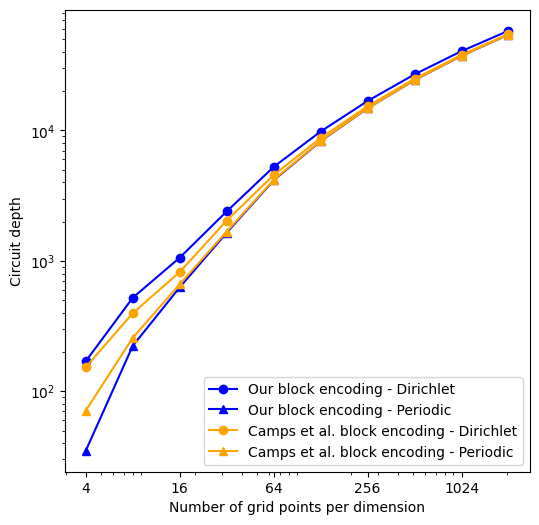

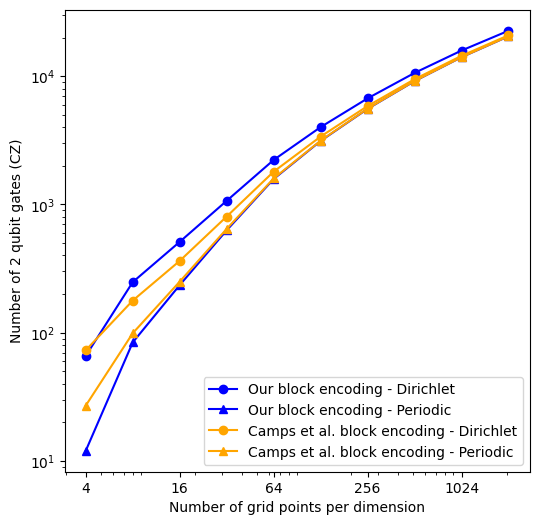

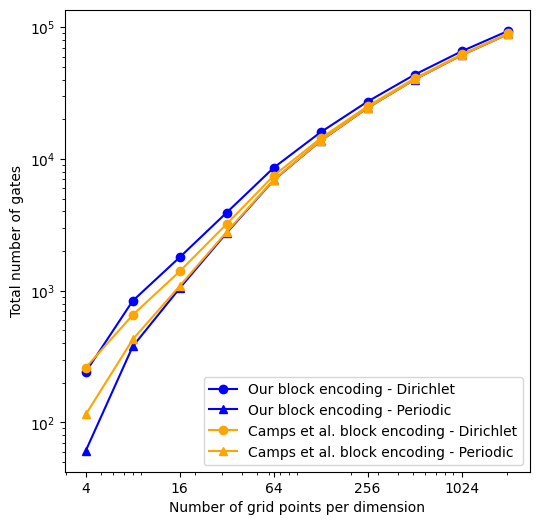

In [6]:
# 1D Laplacians with Dirichlet/periodic BCs
basis_gates = ["cz", "id", "rx", "rz", "rzz", "sx", "x"]  # Heron QPU basis gates

nqs = list(range(2, 12))
npoints = 2 ** np.array(nqs)

our_be_dbc_depth = []
our_be_pbc_depth = []
camps_be_dbc_depth = []
camps_be_pbc_depth = []

our_be_dbc_2qg = []
our_be_pbc_2qg = []
camps_be_dbc_2qg = []
camps_be_pbc_2qg = []

our_be_dbc_total = []
our_be_pbc_total = []
camps_be_dbc_total = []
camps_be_pbc_total = []

for nq in nqs:
    # Dirichlet BCs
    # - Our block-encoding
    qc = generate_laplacian_block_encoding([nq], save_unitary=False)
    transpiled = transpile(qc, basis_gates=basis_gates)
    counts = transpiled.count_ops()
    twoq_count = counts["cz"] + counts["rzz"]

    our_be_dbc_depth.append(transpiled.depth())
    our_be_dbc_2qg.append(twoq_count)
    our_be_dbc_total.append(sum(counts.values()))

    # - Camps et al.
    qc = camps_banded_circulant_mat(nq, 0.5, -0.25, -0.25, True, False)
    transpiled = transpile(qc, basis_gates=basis_gates)
    counts = transpiled.count_ops()
    twoq_count = counts["cz"] + counts["rzz"]

    camps_be_dbc_depth.append(transpiled.depth())
    camps_be_dbc_2qg.append(twoq_count)
    camps_be_dbc_total.append(sum(counts.values()))

    # Periodic BCs
    # - Our block-encoding
    qc = generate_laplacian_block_encoding([nq], bcs=["periodic"], save_unitary=False)
    transpiled = transpile(qc, basis_gates=basis_gates)
    counts = transpiled.count_ops()
    twoq_count = counts["cz"] + counts["rzz"]

    our_be_pbc_depth.append(transpiled.depth())
    our_be_pbc_2qg.append(twoq_count)
    our_be_pbc_total.append(sum(counts.values()))

    # - Camps et al.
    qc = camps_banded_circulant_mat(nq, 0.5, -0.25, -0.25, False, False)
    transpiled = transpile(qc, basis_gates=basis_gates)
    counts = transpiled.count_ops()
    twoq_count = counts["cz"] + counts["rzz"]

    camps_be_pbc_depth.append(transpiled.depth())
    camps_be_pbc_2qg.append(twoq_count)
    camps_be_pbc_total.append(sum(counts.values()))


plt.figure(figsize=(6, 6))
plt.plot(
    npoints,
    our_be_dbc_depth,
    "o-",
    color="blue",
    label="Our block encoding - Dirichlet",
)
plt.plot(
    npoints, our_be_pbc_depth, "^-", color="blue", label="Our block encoding - Periodic"
)
plt.plot(
    npoints,
    camps_be_dbc_depth,
    "o-",
    color="orange",
    label="Camps et al. block encoding - Dirichlet",
)
plt.plot(
    npoints,
    camps_be_pbc_depth,
    "^-",
    color="orange",
    label="Camps et al. block encoding - Periodic",
)
plt.xscale("log")
plt.xlabel("Number of grid points per dimension")
plt.yscale("log")
plt.ylabel("Circuit depth")
plt.xticks(npoints[::2], labels=npoints[::2])
plt.legend()
plt.show()


plt.figure(figsize=(6, 6))
plt.plot(
    npoints, our_be_dbc_2qg, "o-", color="blue", label="Our block encoding - Dirichlet"
)
plt.plot(
    npoints, our_be_pbc_2qg, "^-", color="blue", label="Our block encoding - Periodic"
)
plt.plot(
    npoints,
    camps_be_dbc_2qg,
    "o-",
    color="orange",
    label="Camps et al. block encoding - Dirichlet",
)
plt.plot(
    npoints,
    camps_be_pbc_2qg,
    "^-",
    color="orange",
    label="Camps et al. block encoding - Periodic",
)
plt.xscale("log")
plt.xlabel("Number of grid points per dimension")
plt.yscale("log")
plt.ylabel("Number of 2 qubit gates (CZ)")
plt.xticks(npoints[::2], labels=npoints[::2])
plt.legend()
plt.show()


plt.figure(figsize=(6, 6))
plt.plot(
    npoints,
    our_be_dbc_total,
    "o-",
    color="blue",
    label="Our block encoding - Dirichlet",
)
plt.plot(
    npoints, our_be_pbc_total, "^-", color="blue", label="Our block encoding - Periodic"
)
plt.plot(
    npoints,
    camps_be_dbc_total,
    "o-",
    color="orange",
    label="Camps et al. block encoding - Dirichlet",
)
plt.plot(
    npoints,
    camps_be_pbc_total,
    "^-",
    color="orange",
    label="Camps et al. block encoding - Periodic",
)
plt.xscale("log")
plt.xlabel("Number of grid points per dimension")
plt.yscale("log")
plt.ylabel("Total number of gates")
plt.xticks(npoints[::2], labels=npoints[::2])
plt.legend()
plt.show()